In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# =========================
# Experiment settings
# =========================

shots = 1024

n_values = [1, 3, 5, 7, 9]

theta_values = np.radians(np.arange(0, 181, 10))

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

label_map = {
    "no_error": "No Error",
    "E1_before_H": r"$\mathcal{E}_1$ before first $H$",
    "E2_after_first_H": r"$\mathcal{E}_2$ after first $H$",
    "E3_after_oracle": r"$\mathcal{E}_3$ after oracle",
    "E4_after_final_H": r"$\mathcal{E}_4$ after final $H$",
}

In [3]:
# =========================
# Helper functions
# =========================

def get_success_probability(function_name, P0):
    """
    For constant functions, DJA succeeds when output is 0...0.
    For balanced functions, DJA succeeds when output is not 0...0.
    """
    if function_name in ["constant_0", "constant_1"]:
        return P0

    if function_name == "balanced_parity":
        return 1 - P0

    raise ValueError(f"Unknown function: {function_name}")


def standard_error(p, shots):
    return np.sqrt(p * (1 - p) / shots)

In [4]:
# =========================
# Run simulation with shots
# =========================

results = []

for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        # Original DJA without error
        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots
        success_ref = get_success_probability(function_name, P0_ref)

        for theta in theta_values:
            theta_deg = np.degrees(theta)

            for axis_name, axis in axes.items():

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": theta_deg,
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "success_probability": success_ref,
                    "std_error": standard_error(success_ref, shots),
                    "shots": shots,
                })

                # E1, E2, E3, E4
                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots
                    success_error = get_success_probability(
                        function_name, P0_error
                    )

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": theta_deg,
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "success_probability": success_error,
                        "std_error": standard_error(success_error, shots),
                        "shots": shots,
                    })

df = pd.DataFrame(results)

print(df.shape)
df.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9
(4275, 11)


,n,theta_rad,theta_deg,axis,target_qubit,function,error_position,P0,success_probability,std_error,shots
0,1,0.0,0.0,X,0,constant_1,no_error,1.0,1.0,0.0,1024
1,1,0.0,0.0,X,0,constant_1,E1_before_H,1.0,1.0,0.0,1024
2,1,0.0,0.0,X,0,constant_1,E2_after_first_H,1.0,1.0,0.0,1024
3,1,0.0,0.0,X,0,constant_1,E3_after_oracle,1.0,1.0,0.0,1024
4,1,0.0,0.0,X,0,constant_1,E4_after_final_H,1.0,1.0,0.0,1024


In [5]:
# =========================
# Save results
# =========================

df.to_csv("dja_error_results_n1_3_5_7_9_shots_1024.csv", index=False)

In [6]:
# =========================
# Plot function
# =========================

def plot_error_positions(df, n_plot, axis_plot, function_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["axis"] == axis_plot) &
        (df["function"] == function_plot)
    ]

    if plot_df.empty:
        print(
            f"No data found for n={n_plot}, "
            f"axis={axis_plot}, function={function_plot}"
        )
        return

    plt.figure(figsize=(9, 6))

    for error_pos in [
        "no_error",
        "E1_before_H",
        "E2_after_first_H",
        "E3_after_oracle",
        "E4_after_final_H",
    ]:
        subset = plot_df[plot_df["error_position"] == error_pos]

        plt.plot(
            subset["theta_deg"],
            subset["success_probability"],
            linewidth=2,
            label=label_map[error_pos]
        )

    plt.xlabel(r"Rotation angle $\theta$ (degrees)")
    plt.ylabel("Success probability")
    plt.title(
        f"DJA success under rotation errors\n"
        f"function={function_plot}, n={n_plot}, axis={axis_plot}, shots={shots}"
    )

    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Error position")
    plt.tight_layout()
    plt.show()

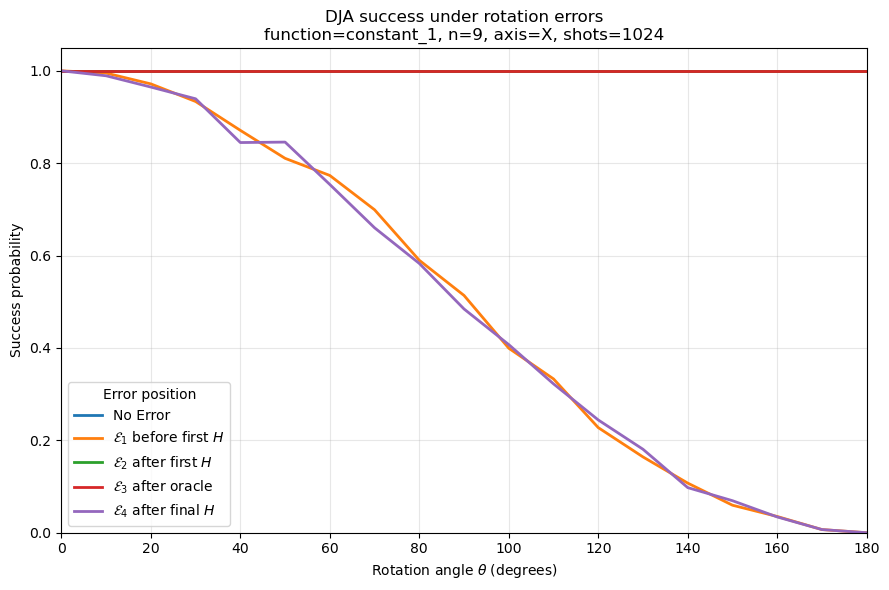

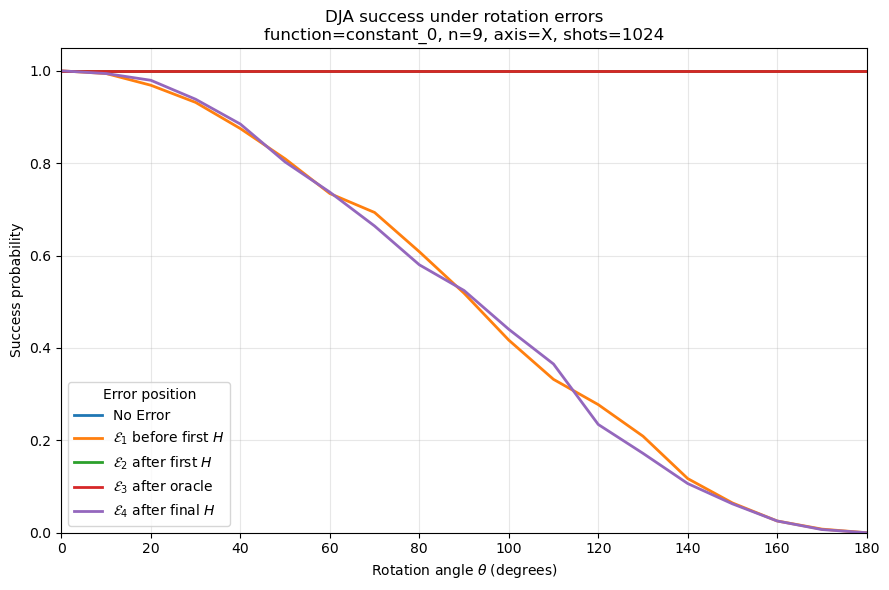

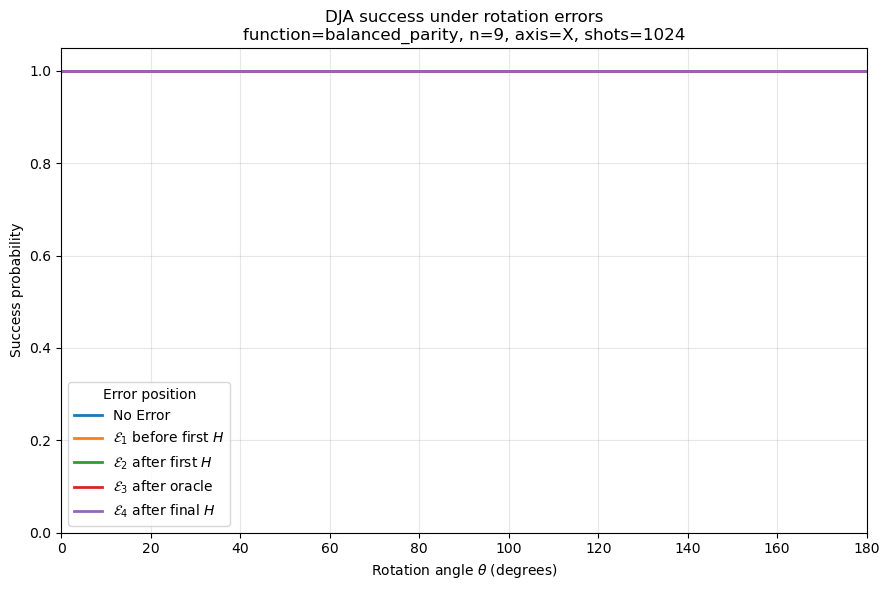

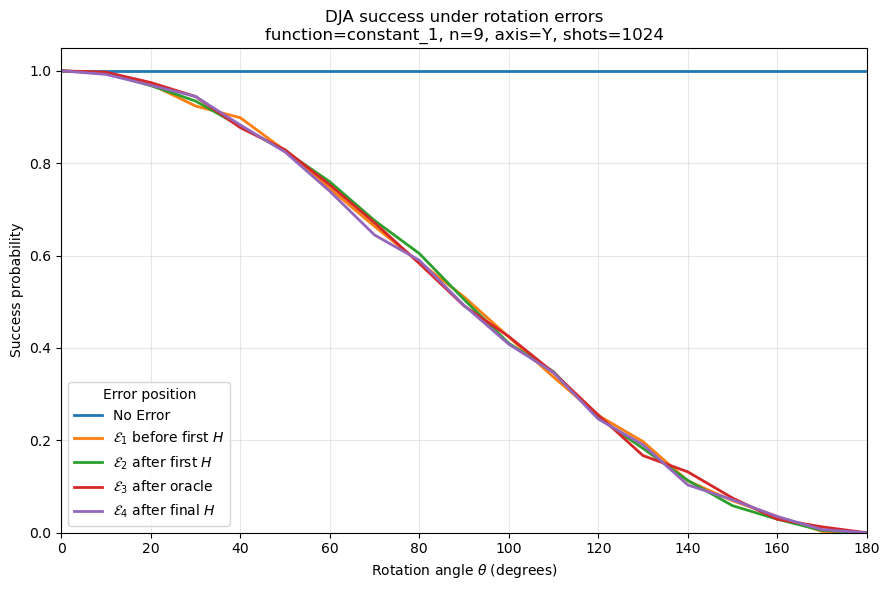

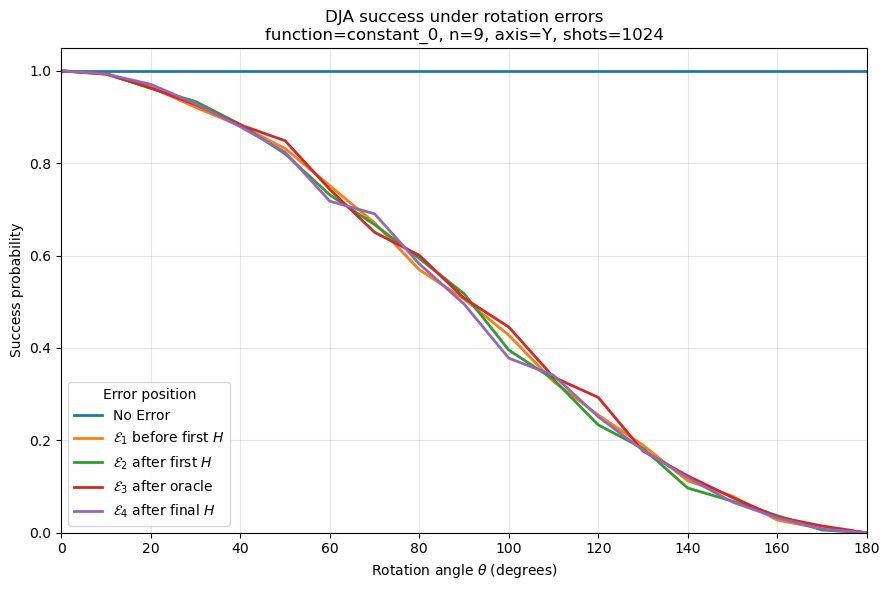

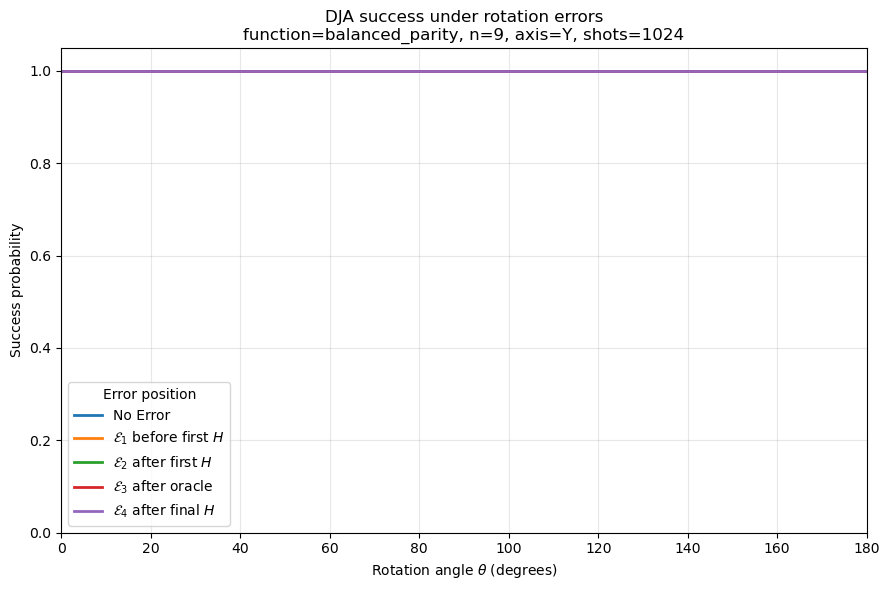

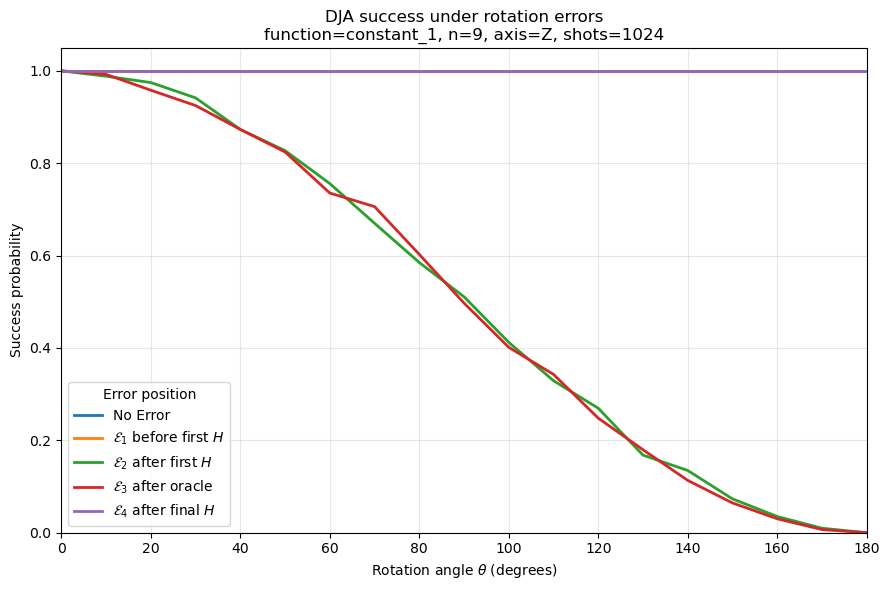

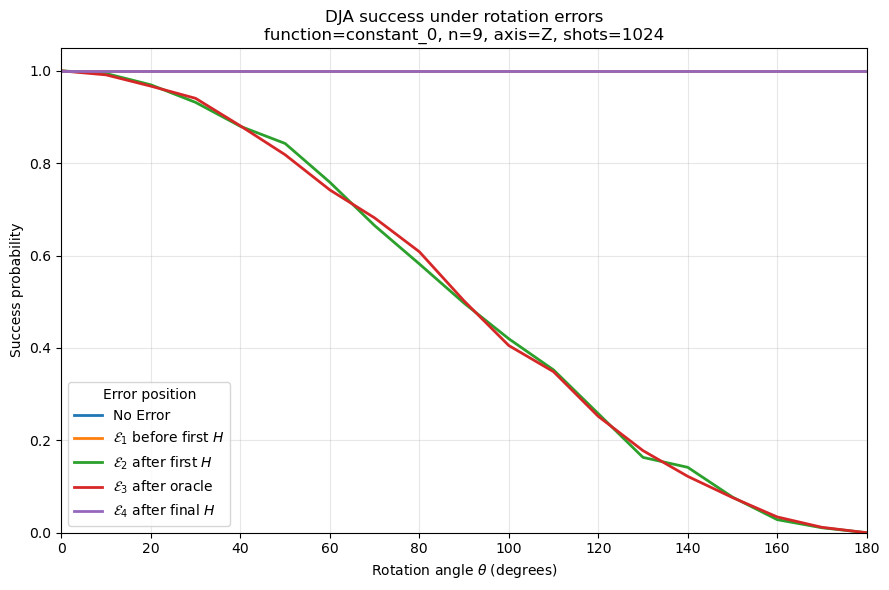

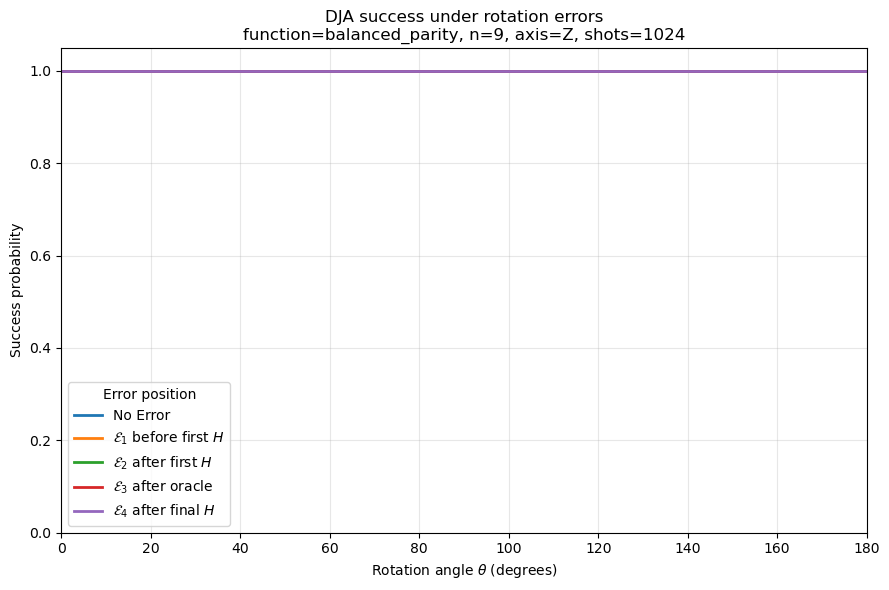

In [7]:
# =========================
# Plots for n = 9
# =========================

plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="constant_1")
plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="constant_0")
plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="balanced_parity")

plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="constant_1")
plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="constant_0")
plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="balanced_parity")

plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="constant_1")
plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="constant_0")
plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="balanced_parity")

The experiment investigates the effect of single-qubit rotation errors on the Deutsch–Jozsa Algorithm. Four error positions were considered: E1 before the first Hadamard gates, E2 after the first Hadamard gates, E3 after the oracle, and E4 after the final Hadamard gates. The rotation angle θ was varied from 0° to 180° in steps of 1°. For each circuit configuration, 1024 measurement shots were used.

The number of input qubits was selected as n = 1, 3, 5, 7, and 9. This interval provides a feasible range for simulation while still showing how the algorithm behaves as the system size increases. The middle qubit was selected as the target qubit for the rotation error. Results were collected for X, Y, and Z rotation axes and for constant and balanced functions.